In [1]:
%load_ext autoreload
%autoreload 2

from spatial_tcr.utils import switch_cwd_to_root

switch_cwd_to_root()

from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import spatialtools as st
from scipy.sparse import csr_matrix

figure_dir = "figures"
st.utils.setup_plotting(figure_dir)

Changed working directory to /bonn-epyc/projects/dschaub/analysis-projects/spatial-tcr
Arial font found!


In [2]:
adata = sc.read_h5ad("data/xenium/processed/03-kidney_tcr_classified.h5ad")

In [3]:
adata.obs["sample"].unique()

['XETG00088__0029040__Region_2__20240719__095641', 'XETG00088__0029040__Region_4__20240719__095642', 'XETG00088__0029041__Region_3__20240719__095642', 'XETG00088__0029041__Region_5__20240719__095642', 'XETG00088__0029040__Region_7__20240719__095642', ..., 'XETG00088__0029041__Region_8__20240719__095642', 'XETG00088__0029041__Region_7__20240719__095642', 'XETG00088__0029041__Region_6__20240719__095642', 'XETG00088__0029041__Region_1__20240719__095642', 'XETG00088__0029040__Region_5__20240719__095642']
Length: 13
Categories (13, object): ['XETG00088__0029040__Region_2__20240719__095641', 'XETG00088__0029040__Region_3__20240719__095641', 'XETG00088__0029040__Region_4__20240719__095642', 'XETG00088__0029040__Region_5__20240719__095642', ..., 'XETG00088__0029041__Region_5__20240719__095642', 'XETG00088__0029041__Region_6__20240719__095642', 'XETG00088__0029041__Region_7__20240719__095642', 'XETG00088__0029041__Region_8__20240719__095642']

In [4]:
# only concentrate on the vgenes
av = [x for x in adata.var_names if x.startswith("TRAV")]
bv = [x for x in adata.var_names if x.startswith("TRBV")]
gv = [x for x in adata.var_names if x.startswith("TRGV")]
dv = [x for x in adata.var_names if x.startswith("TRDV")]

In [5]:
print(len(av), len(bv), len(dv), len(gv))
print(len(av + bv + dv + gv))

54 61 3 14
132


In [6]:
vdata = adata[:, av + bv + dv + gv].copy()
vgenes_toremove = []

# V gene and celltype

In [7]:
def _get_countfreq(vals, ts):
    total = vals.sum()
    ts = list(set(vals.index).intersection(set(ts)))
    try:
        tcells = vals[ts].sum()
    except KeyError:
        tcells = 0
    return tcells, total


def get_ratio(vdata, vgenes, cut=False):
    """Return pandas Series with v genes in index and the fraction of Tcell compared to all cells with the specific vgene in values."""
    ratio = []
    col = "counts"
    if cut:
        col = "counts_cut"
    for v in vdata[:, vgenes].layers[col].toarray().astype(bool).transpose():
        # We are counting the number of cells which has exoressed v gene at least one time
        # print(vdata[v].obs['cell_type_no_tcr'].value_counts())
        vals = vdata[v].obs["cell_type_no_tcr"].value_counts()
        ts = ["T"]
        tcells, total = _get_countfreq(vals, ts)
        ratio.append(tcells / total)
        # ix += 1
    return pd.Series(ratio, index=vgenes)


def get_countfreq(vdata, vgenes):
    basecount = []
    for v in vdata[:, vgenes].layers["counts"].toarray().astype(bool).transpose():
        vals = vdata[v].obs["cell_type_no_tcr"].value_counts()
        ts = ["T"]
        tcells, total = _get_countfreq(vals, ts)
        basecount.append(tcells)
    cutcount = []
    for v in vdata[:, vgenes].layers["counts_cut"].toarray().astype(bool).transpose():
        vals = vdata[v].obs["cell_type_no_tcr"].value_counts()
        ts = ["T"]
        tcells, total = _get_countfreq(vals, ts)
        cutcount.append(tcells)
    return pd.DataFrame(data={"No_cutoff": basecount, "Cutoff": cutcount}, index=vgenes)

In [8]:
def create_barplot_cutchange(df, gene, genename=""):
    x = np.arange(len(df))
    # Create figure
    fig, ax = plt.subplots(figsize=(8, 5))
    # Plot base bars in gray
    ax.bar(x, df[0], color="gray", label="No cutoff")
    # Add increase/decrease bars
    _ = ["green" if v >= 0 else "red" for v in df[1]]
    # Separate positive (increase) and negative (decrease) changes
    increase = df[1].clip(lower=0)  # Keep only positive values
    decrease = df[1].clip(upper=0)  # Keep only negative values

    # Plot increases (green)
    ax.bar(x, increase, bottom=df[0], color="green", label="Increase with cutoff")

    # Plot decreases (red)
    ax.bar(x, decrease, bottom=df[0], color="red", label="Decrease with cutoff")

    # X-axis labels
    ax.set_xticks(x, gene, rotation=90)
    ax.set_xticklabels(df.index)  # Use row indices as labels

    # Labels and title
    ax.set_ylabel(f"T cell with {genename}/ All cells with {genename}")
    ax.set_xlabel(f"{genename} gene")
    ax.set_title(
        f"{genename} specific fraction of T cells with Cutoff Increase/Decrease"
    )

    # Add a legend
    ax.legend()
    plt.ylim(0, 0.85)
    plt.xlim(-1, len(df))
    # Show plot
    plt.tight_layout()
    plt.savefig(
        f"{figure_dir}/{genename}_fractioninTcell.pdf", dpi=300
    )  # ToDo Error if image_promiscuous dir does not exists

In [9]:
# Changes after cut?
vdata.layers["counts_cut"] = csr_matrix(
    np.clip(
        vdata.layers["counts"].toarray() - 1,
        a_min=0,
        a_max=vdata.layers["counts"].max(),
    )
)

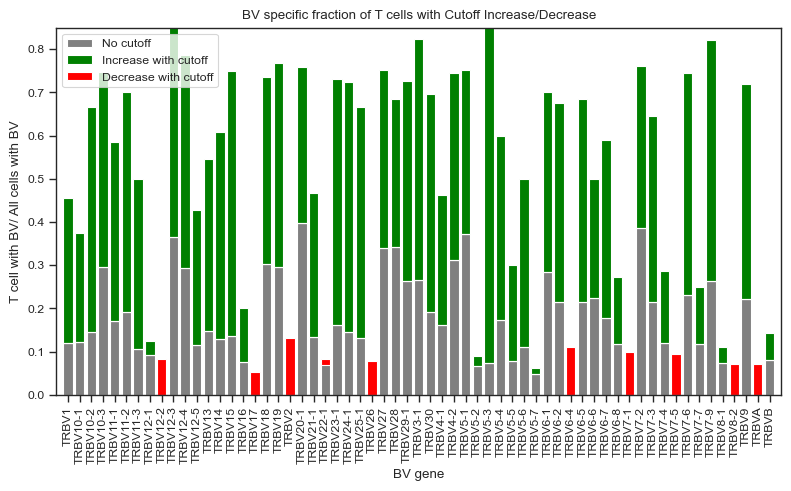

In [10]:
gene = bv
srs = get_ratio(vdata, gene, cut=True) - get_ratio(vdata, gene)
df = pd.concat([get_ratio(vdata, gene), srs], axis=1)
create_barplot_cutchange(df, gene, "BV")
vgenes_toremove.append(df[df[1] < 0].index)

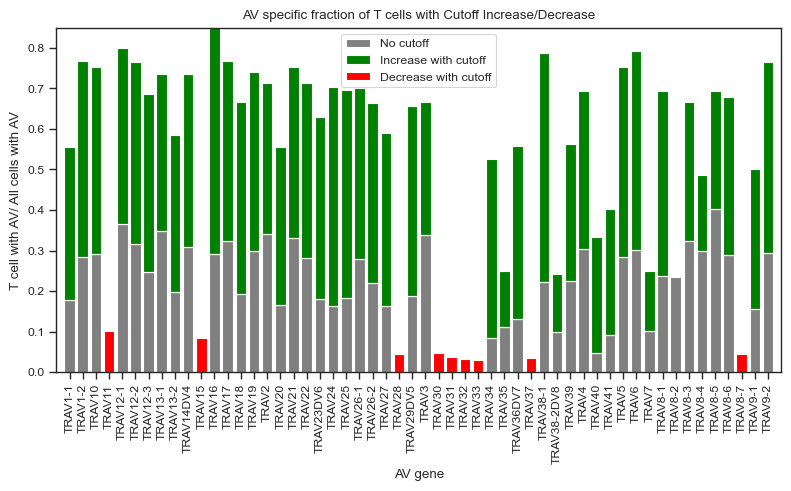

In [11]:
gene = av
srs = get_ratio(vdata, gene, cut=True) - get_ratio(vdata, gene)
df = pd.concat([get_ratio(vdata, gene), srs], axis=1)
create_barplot_cutchange(df, gene, "AV")
vgenes_toremove.append(df[df[1] < 0].index)

# Remove V genes more highly (>1) expressed in non-T cells than in T cells.

In [12]:
srs = get_countfreq(vdata, av + bv)
# srs.to_csv(
#     "image_promiscuous/av_and_bv_nocutoff_tcell_freqcount.csv"
# )  # ToDo Error if image_promiscuous dir does not exists

In [13]:
vgenes_toremove = [_ for ix in vgenes_toremove for _ in list(ix)]
vdata = vdata[:, ~vdata.var_names.isin(vgenes_toremove)]

In [14]:
print(len(av), len(bv))
bv = sorted(set(bv).difference(set(vgenes_toremove)))
av = sorted(set(av).difference(set(vgenes_toremove)))
print(len(av), len(bv))

54 61
44 51


In [15]:
print(vgenes_toremove)

['TRBV12-2', 'TRBV17', 'TRBV2', 'TRBV22-1', 'TRBV26', 'TRBV6-4', 'TRBV7-1', 'TRBV7-5', 'TRBV8-2', 'TRBVA', 'TRAV11', 'TRAV15', 'TRAV28', 'TRAV30', 'TRAV31', 'TRAV32', 'TRAV33', 'TRAV37', 'TRAV8-2', 'TRAV8-7']


# Vgene and wrongly coexpression BV

In [16]:
bvdata = vdata[vdata.obs.cell_type_no_tcr.isin(["T"]), bv].copy()

In [17]:
multb = (
    bvdata.layers["counts"].astype(bool).toarray().sum(1)
)  # Count how many TRBV genes are per cell
mat = (
    bvdata[multb > 1].layers["counts"].astype(bool).toarray()
)  # show all cells with more than one TRBV
combs = [
    list(combinations(np.where(row)[0], 2)) for row in mat
]  # calculate all combinations
# weight the combinations (all combination within one cell should sum to 1)
coexpr = np.zeros((len(bv), len(bv)))
for pairs in combs:
    weight = 1 / len(pairs)
    for i, j in pairs:
        coexpr[i, j] += weight
        coexpr[j, i] += weight

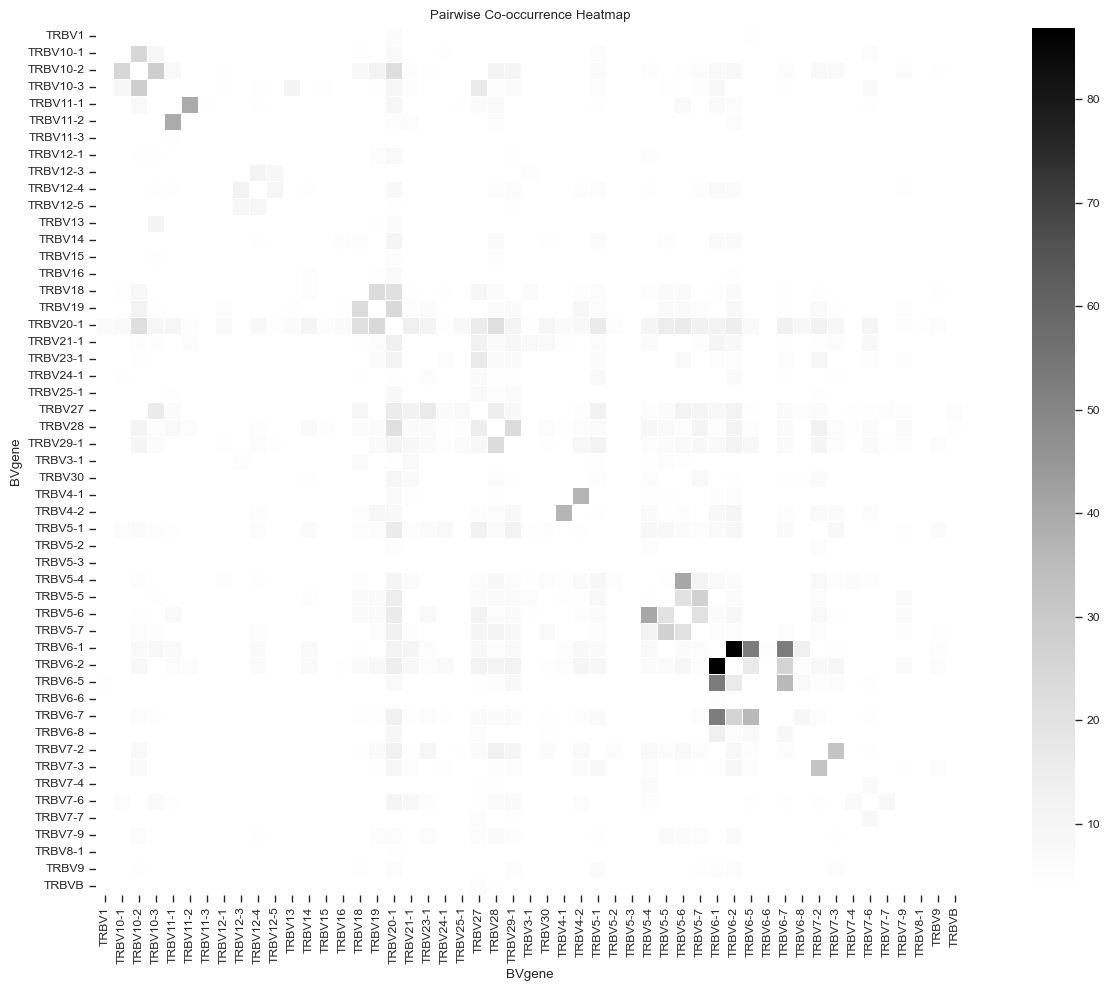

In [18]:
# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    coexpr, annot=False, cmap="Greys", square=True, linewidths=0.5, vmin=coexpr.mean()
)

# Labels and title
plt.xticks(np.arange(len(bv)) + 0.5, bv, rotation=90)
plt.yticks(np.arange(len(bv)) + 0.5, bv, rotation=00)
plt.xlabel("BVgene")
plt.ylabel("BVgene")
plt.title("Pairwise Co-occurrence Heatmap")
plt.tight_layout()
plt.savefig(
    f"{figure_dir}/BV_coexpression.pdf", dpi=300
)  # ToDo Error if image_promiscuous dir does not exists

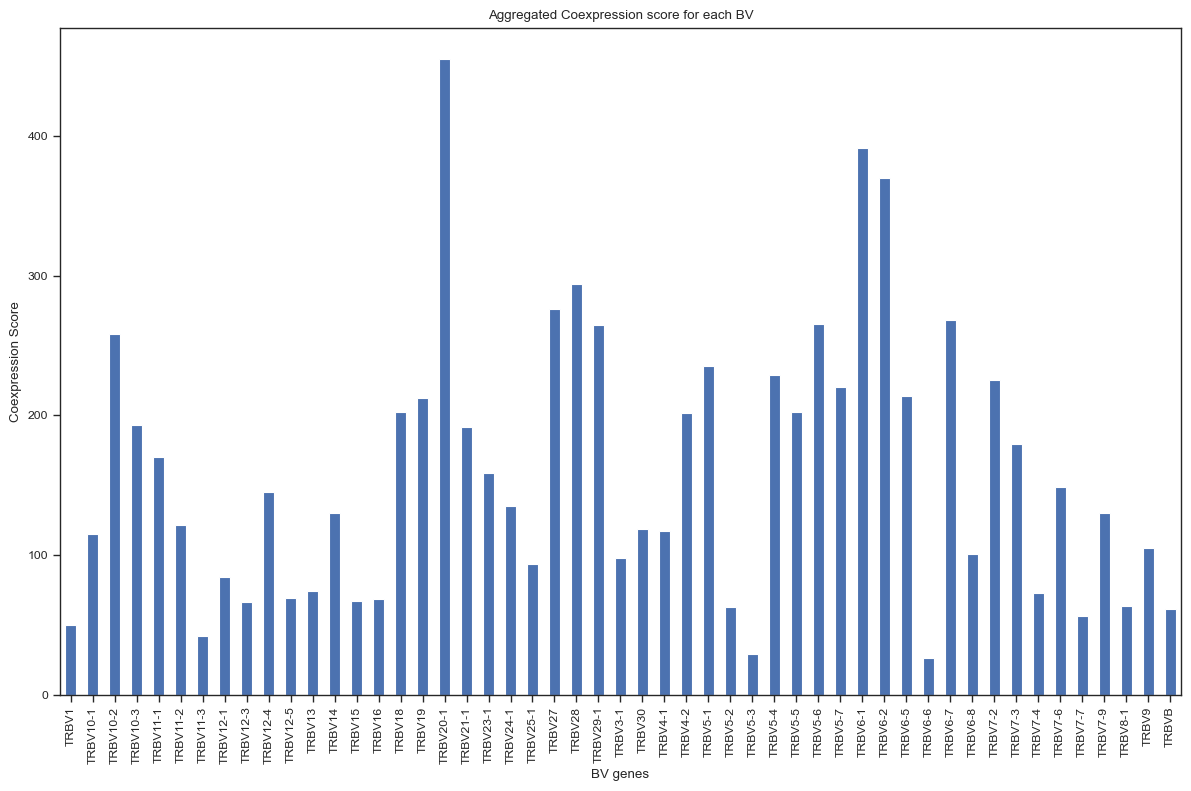

In [19]:
plt.figure(figsize=(12, 8))
pd.Series(coexpr.sum(1)).plot(kind="bar")
plt.xticks(np.arange(len(bv)), bv)
plt.ylabel("Coexpression Score")
plt.xlabel("BV genes")
plt.title("Aggregated Coexpression score for each BV")
plt.tight_layout()
plt.savefig(
    f"{figure_dir}/BV_coexpression_aggregated.png", dpi=300
)  # ToDo Error if image_promiscuous dir does not exists

# Vgene and wrongly coexpression AV

In [20]:
avdata = vdata[vdata.obs.cell_type_no_tcr.isin(["T"]), av].copy()

In [21]:
multa = (
    avdata.layers["counts"].astype(bool).toarray().sum(1)
)  # Count how many TRAV genes are per cell
mat = (
    avdata[multa > 1].layers["counts"].astype(bool).toarray()
)  # show all cells with more than one TRAV
combs = [
    list(combinations(np.where(row)[0], 2)) for row in mat
]  # calculate all combinations
# weight the combinations (all combination within one cell should sum to 1)
coexpr = np.zeros((len(av), len(av)))
for pairs in combs:
    weight = 1 / len(pairs)
    for i, j in pairs:
        coexpr[i, j] += weight
        coexpr[j, i] += weight

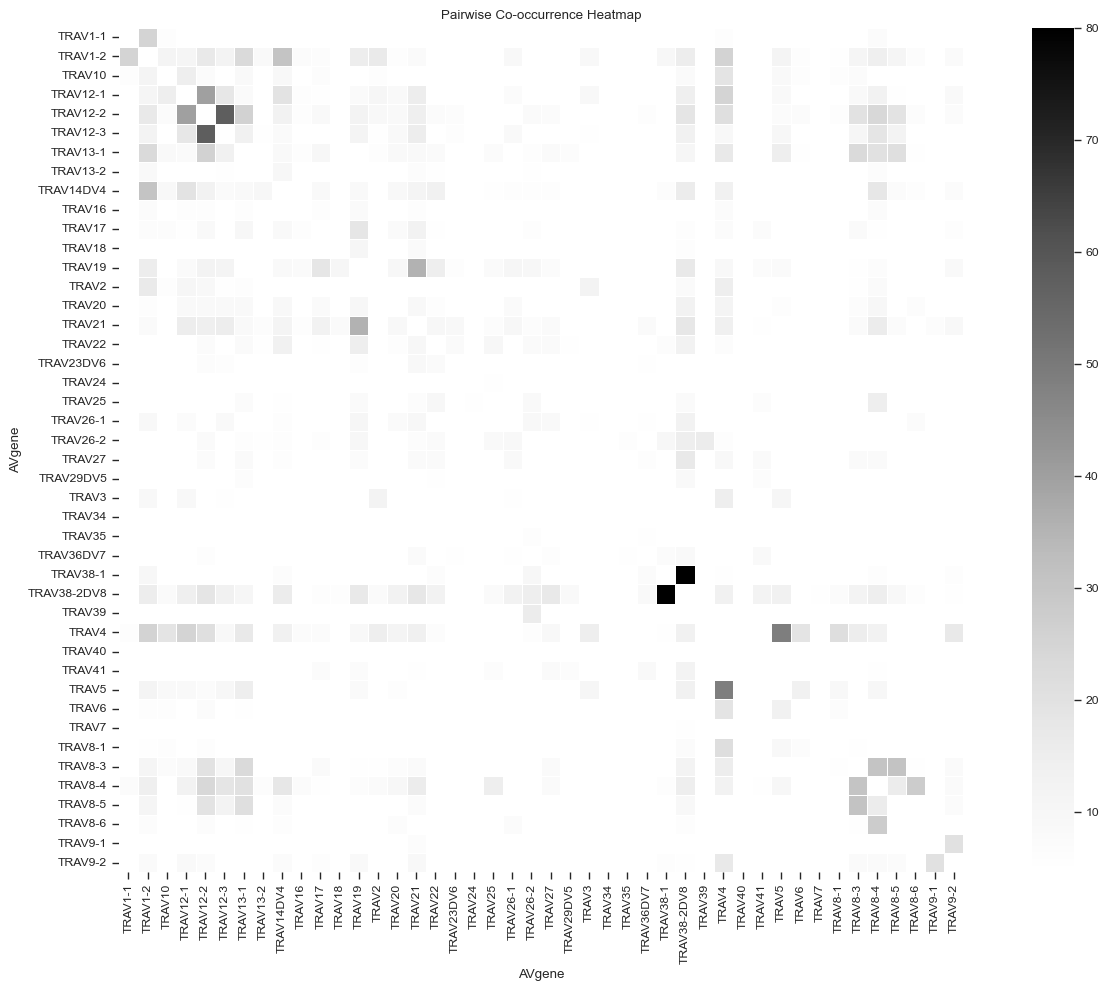

In [22]:
# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    coexpr,
    annot=False,
    cmap="Greys",
    square=True,
    linewidths=0.5,
    vmin=coexpr.mean(),
    vmax=80,
)

# Labels and title
plt.xticks(np.arange(len(av)) + 0.5, av, rotation=90)
plt.yticks(np.arange(len(av)) + 0.5, av, rotation=00)
plt.xlabel("AVgene")
plt.ylabel("AVgene")
plt.title("Pairwise Co-occurrence Heatmap")
plt.tight_layout()
plt.savefig(
    f"{figure_dir}/AV_coexpression.pdf", dpi=300
)  # ToDo Error if image_promiscuous dir does not exists

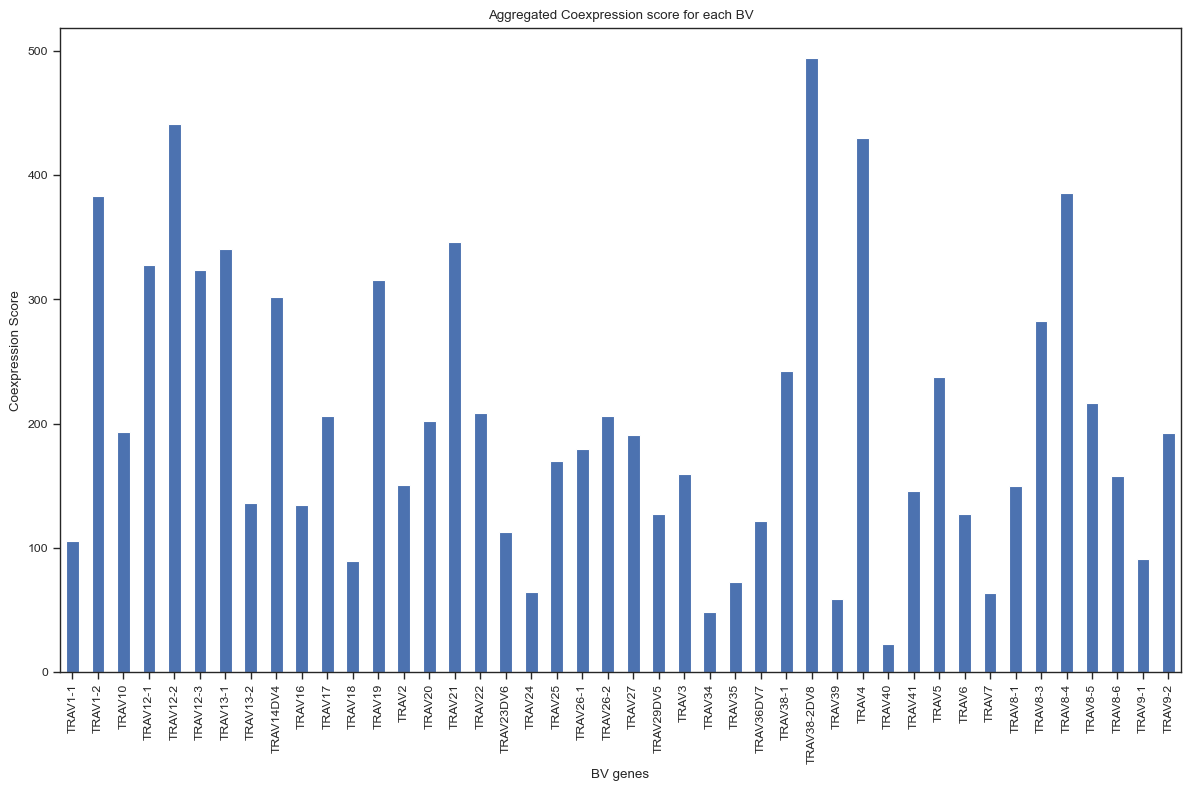

In [23]:
plt.figure(figsize=(12, 8))
pd.Series(coexpr.sum(1)).plot(kind="bar")
plt.xticks(np.arange(len(av)), av)
plt.ylabel("Coexpression Score")
plt.xlabel("BV genes")
plt.title("Aggregated Coexpression score for each BV")
plt.tight_layout()
plt.savefig(
    f"{figure_dir}/AV_coexpression_aggregated.png", dpi=300
)  # ToDo Error if image_promiscuous dir does not exists